# Healthcare Prescription Safety & Patient Risk Intelligence Platform

## Machine Learning

### Purpose and goal

Predict **Readmitted = Yes / No** — using the same 30-day readmission definition built.

### Features Selection

- `anchor_age`
- `number_of_diagnoses` (`diagnosis_count` from `clinical_master`)
- `number_of_admissions` (the patient's admission history *before* this stay)
- `admission_type`

### Models

1. Logistic Regression
2. Random Forest

### Evaluation

Accuracy, Precision, Recall, F1 and a confusion matrix for each model.

## 1. Import libraries

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, classification_report,
)
import joblib

pd.set_option("display.max_columns", None)
pd.set_option("display.width", 200)
sns.set_style("whitegrid")

import warnings
warnings.filterwarnings("ignore")

## 2. Load Data (clean version)

In [2]:
PROCESSED = "../Data/Processed"

clinical_master = pd.read_csv(f"{PROCESSED}/clinical_master.csv")
print(clinical_master.shape)
clinical_master.head()

(275, 24)


,subject_id,hadm_id,admittime,dischtime,admission_type,admission_location,discharge_location,insurance,language,marital_status,race,length_of_stay_days,came_via_ed,ed_duration_hours,in_hospital_death,prior_admissions_count,days_to_next_admit,readmitted_30d,gender,anchor_age,deceased,diagnosis_count,primary_diagnosis,age_bracket
0,10000032,22595853,2180-05-06 22:23:00,2180-05-07 17:15:00,URGENT,TRANSFER FROM HOSPITAL,HOME,Other,ENGLISH,WIDOWED,WHITE,0.79,1,4.22,0,0,50.050000,0,F,52,1,8,Other / not mapped,45-59
1,10000032,22841357,2180-06-26 18:27:00,2180-06-27 18:49:00,EW EMER.,EMERGENCY ROOM,HOME,Medicaid,ENGLISH,WIDOWED,WHITE,1.02,1,5.62,0,1,25.740278,1,F,52,1,8,Other / not mapped,45-59
2,10000032,29079034,2180-07-23 12:35:00,2180-07-25 17:55:00,EW EMER.,EMERGENCY ROOM,HOME,Medicaid,ENGLISH,WIDOWED,WHITE,2.22,1,8.10,0,2,11.242361,1,F,52,1,13,Other / not mapped,45-59
3,10000032,25742920,2180-08-05 23:44:00,2180-08-07 17:50:00,EW EMER.,EMERGENCY ROOM,HOSPICE,Medicaid,ENGLISH,WIDOWED,WHITE,1.75,1,4.77,0,3,NaN,0,F,52,1,10,Other / not mapped,45-59
4,10001217,24597018,2157-11-18 22:56:00,2157-11-25 18:00:00,EW EMER.,EMERGENCY ROOM,HOME HEALTH CARE,Other,UNKNOWN,MARRIED,WHITE,6.79,1,7.77,0,0,22.956944,1,F,55,0,10,Other / not mapped,45-59


## 3. Target and Features selection

**Target:** `readmitted_30d` *`— 1`* if the patient was readmitted within 30 days of this discharge, *`0`* otherwise.

**Features:**

- `anchor_age` and `diagnosis_count`: the patient's age, and how many diagnoses were recorded on this admission.

- For "number of admissions," I will use `prior_admissions_count`which correspond to the count of admissions this patient had **before** the current one (not total admission count).

- `admission_type` is categorical (e.g. `URGENT`, `ELECTIVE`, `EW EMER.`) and needs one-hot encoding before it can go into either model.

In [3]:
model_df = clinical_master[[
    "anchor_age", "diagnosis_count", "prior_admissions_count", "admission_type", "readmitted_30d"
]].copy()

model_df = pd.get_dummies(model_df, columns=["admission_type"], drop_first=True)

X = model_df.drop(columns=["readmitted_30d"])
y = model_df["readmitted_30d"]

print("Features:", list(X.columns))
print(f"\nClass balance — Readmitted: {y.mean():.1%}   Not readmitted: {1 - y.mean():.1%}")

Features: ['anchor_age', 'diagnosis_count', 'prior_admissions_count', 'admission_type_DIRECT EMER.', 'admission_type_DIRECT OBSERVATION', 'admission_type_ELECTIVE', 'admission_type_EU OBSERVATION', 'admission_type_EW EMER.', 'admission_type_OBSERVATION ADMIT', 'admission_type_SURGICAL SAME DAY ADMISSION', 'admission_type_URGENT']

Class balance — Readmitted: 19.3%   Not readmitted: 80.7%


**Findings:**
Only about 1 in 5 admissions is followed by a `30-day readmission`. 
This **class imbalance** matters for both the train/test split and a model that just predicts "No" for everyone would already score **~81% accuracy** while being completely useless, so accuracy alone cannot be trusted here.

## 4. Train / Test Split

`stratify=y` keeps the same ~81/19 Yes/No ratio in both the training and test sets (due the imbalance)
`random_state=42` makes the split reproducible.

In [4]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42, stratify=y
)

print(f"Train: {X_train.shape[0]} admissions   Test: {X_test.shape[0]} admissions")
print(f"Readmissions in test set: {y_test.sum()} of {len(y_test)}")

Train: 206 admissions   Test: 69 admissions
Readmissions in test set: 13 of 69


In [5]:
# Using scaling for Logistic Regression
# Logistic Regression is a distance/gradient-based model, so features on very different scales (age in years vs. diagnosis counts) can distort it.

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

## 5. Model 1 — Logistic Regression

- **`Tuning:`** as I mentioned above due to 81/19 (Yes/No ratio) I set the `class_weight="balanced"` corrects a default logistic regression that would just predict "No" most of the time and still look accurate because only ~19% of admission is positive. 

In [6]:
logreg = LogisticRegression(max_iter=1000, class_weight="balanced", random_state=42)
logreg.fit(X_train_scaled, y_train)
y_pred_lr = logreg.predict(X_test_scaled)

lr_metrics = {
    "accuracy": accuracy_score(y_test, y_pred_lr),
    "precision": precision_score(y_test, y_pred_lr, zero_division=0),
    "recall": recall_score(y_test, y_pred_lr, zero_division=0),
    "f1": f1_score(y_test, y_pred_lr, zero_division=0),
}
for k, v in lr_metrics.items():
    print(f"{k:10s}: {v:.3f}")

accuracy  : 0.580
precision : 0.265
recall    : 0.692
f1        : 0.383


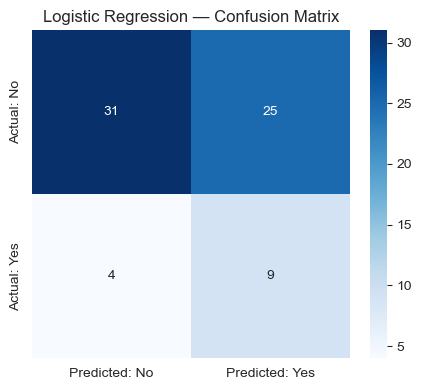

In [7]:
cm_lr = confusion_matrix(y_test, y_pred_lr)

plt.figure(figsize=(4.5, 4))
sns.heatmap(cm_lr, annot=True, fmt="d", cmap="Blues",
            xticklabels=["Predicted: No", "Predicted: Yes"],
            yticklabels=["Actual: No", "Actual: Yes"])
plt.title("Logistic Regression — Confusion Matrix")
plt.tight_layout()
plt.show()

**Findings:**

Accuracy  : 0.580 |
Precision : 0.265 |
Recall    : 0.692 |
F1        : 0.383 |


**Model Performance:** Model made a mistake when predicted "No" for actual readmission (bottom-left) then predicted "Yes" but no actual readmission happened. In order to catch true admissions **Recall** should be prioritized.

## 6. Model 2 — Random Forest

**Tuning:** with only 275 admissions total,in order to keep the model Random Forest honest I constrain it:
- `max_depth=5` — stops trees from growing deep enough to carve out a leaf for almost every individual patient.
- `min_samples_leaf=5` — every leaf must represent at least 5 admissions, not 1, so a single unusual patient can't define a rule on its own.
- `class_weight="balanced"` — same imbalance correction as the logistic regression.

In [8]:
rf = RandomForestClassifier(
    n_estimators=200,
    max_depth=5,
    min_samples_leaf=5,
    class_weight="balanced",
    random_state=42,
)
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)

rf_metrics = {
    "accuracy": accuracy_score(y_test, y_pred_rf),
    "precision": precision_score(y_test, y_pred_rf, zero_division=0),
    "recall": recall_score(y_test, y_pred_rf, zero_division=0),
    "f1": f1_score(y_test, y_pred_rf, zero_division=0),
}
for k, v in rf_metrics.items():
    print(f"{k:10s}: {v:.3f}")

accuracy  : 0.580
precision : 0.250
recall    : 0.615
f1        : 0.356


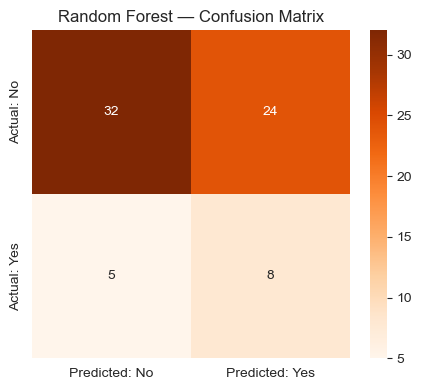

In [9]:
cm_rf = confusion_matrix(y_test, y_pred_rf)

plt.figure(figsize=(4.5, 4))
sns.heatmap(cm_rf, annot=True, fmt="d", cmap="Oranges",
            xticklabels=["Predicted: No", "Predicted: Yes"],
            yticklabels=["Actual: No", "Actual: Yes"])
plt.title("Random Forest — Confusion Matrix")
plt.tight_layout()
plt.show()

## 7. Model Comparison

- A *`single 69-admission test`* set is small enough that one particular split could flatter or penalize either model by chance.
- **5-fold cross-validation** re-splits the data 5 different ways and averages the result, giving a steadier read on which model actually generalizes better.

In [10]:
results_df = pd.DataFrame([
    {"model": "Logistic Regression", **lr_metrics},
    {"model": "Random Forest", **rf_metrics},
]).set_index("model").round(3)

results_df

,accuracy,precision,recall,f1
model,,,,
Logistic Regression,0.58,0.265,0.692,0.383
Random Forest,0.58,0.250,0.615,0.356


In [11]:
X_scaled_full = scaler.fit_transform(X)

cv_lr = cross_val_score(
    LogisticRegression(max_iter=1000, class_weight="balanced", random_state=42),
    X_scaled_full, y, cv=5, scoring="f1",
)
cv_rf = cross_val_score(
    RandomForestClassifier(n_estimators=200, max_depth=5, min_samples_leaf=5,
                            class_weight="balanced", random_state=42),
    X, y, cv=5, scoring="f1",
)

print(f"Logistic Regression — CV F1: {cv_lr.mean():.3f} +/- {cv_lr.std():.3f}   (folds: {cv_lr.round(2)})")
print(f"Random Forest        — CV F1: {cv_rf.mean():.3f} +/- {cv_rf.std():.3f}   (folds: {cv_rf.round(2)})")


Logistic Regression — CV F1: 0.260 +/- 0.058   (folds: [0.21 0.33 0.19 0.32 0.26])
Random Forest        — CV F1: 0.153 +/- 0.095   (folds: [0.   0.21 0.08 0.23 0.24])


**Findings:**

Logistic Regression — CV F1: 0.260 +/- 0.058   (folds: [0.21 0.33 0.19 0.32 0.26])
Random Forest        — CV F1: 0.158 +/- 0.100   (folds: [0.   0.18 0.1  0.27 0.24])

- `Logistic Regression` comes out ahead of `Random Forest` on F1, both on the single test split and across cross-validation folds. (simpler model was better than powerful ensemble) 
- If I had the full MIMIC dataset, Random Forest would have enough data to use its extra flexibility productively instead of overfitting with it.

## 8. Feature Importance

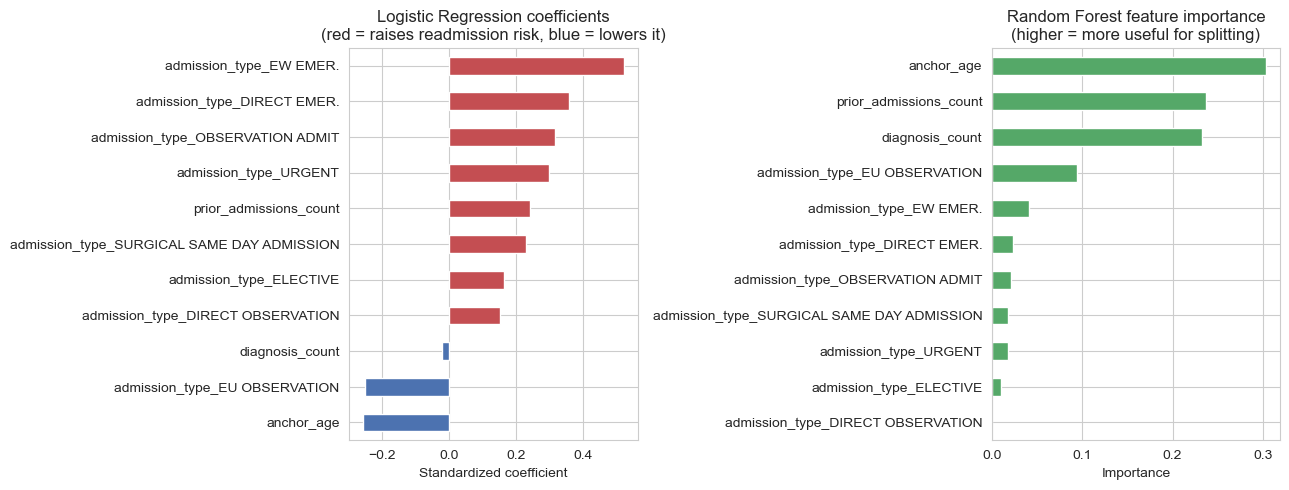

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

coefs = pd.Series(logreg.coef_[0], index=X.columns).sort_values()
colors_lr = ["#C44E52" if v > 0 else "#4C72B0" for v in coefs]
coefs.plot(kind="barh", ax=axes[0], color=colors_lr)
axes[0].set_title("Logistic Regression coefficients\n(red = raises readmission risk, blue = lowers it)")
axes[0].set_xlabel("Standardized coefficient")

importances = pd.Series(rf.feature_importances_, index=X.columns).sort_values()
importances.plot(kind="barh", ax=axes[1], color="#55A868")
axes[1].set_title("Random Forest feature importance\n(higher = more useful for splitting)")
axes[1].set_xlabel("Importance")

plt.tight_layout()
plt.show()

Random Forest's importance ranking and Logistic Regression's largest-magnitude coefficients broadly agree on the same top drivers: **admission history** (`prior_admissions_count`), **diagnosis burden** (`diagnosis_count`), and **age** all show up as meaningful, alongside a few specific `admission_type` categories (emergency-route admissions in particular). That agreement between two very differently-built models is a good sign the pattern is real, not an artifact of one model's assumptions.

## 9. Clear Healthcare Interpretation

**Model findings:** a patient's admission history and diagnosis burden are the most consistent signals of 30-day readmission risk in this cohort carrying a heavier diagnosis load per visit, are the ones most likely to come back. Certain emergency-route admission types also carry higher predicted risk than elective or observation admissions.

**Model missed:** neither model is accurate or reliable enough for real clinical use yet. Recall and F1 are modest, cross-validation shows wide variance between folds, the root cause: 275 admissions (with only ~55 readmissions) is simply too small a sample to build a dependable predictive model — this notebook demonstrates a correct, leakage-free modeling pipeline, not a production-ready risk score.

**Need for improvement:** 

- Train on the full MIMIC-IV dataset (not the 100-patient demo extract) with more admissions.
- Add richer clinical features to this demo dataset which doesn't include: vital signs, lab results, medication counts, prior ICU stays.

## 10. Save the Model

**`Logistic Regression`** best performing model by F1

In [13]:
import os

best_name = results_df["f1"].idxmax()
best_model = logreg if best_name == "Logistic Regression" else rf
print(f"Saving best model by F1: {best_name}")

joblib.dump(best_model, f"{PROCESSED}/readmission_model.pkl")
joblib.dump(scaler, f"{PROCESSED}/readmission_scaler.pkl")
joblib.dump(list(X.columns), f"{PROCESSED}/readmission_model_features.pkl")

print("Saved to", PROCESSED)

Saving best model by F1: Logistic Regression
Saved to ../Data/Processed


**``The END``** 